In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import re
import os
import pandas as pd
import seaborn as sns
import scvi
import gc
import scipy as sp
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

def colour_tables(feature_series):
    features = list(set(feature_series))
    hex_features = []
    for i in range(len(features)):
        r = np.random.randint(0,200)
        g = np.random.randint(0,200)
        b = np.random.randint(0,200)
        colour = '#{:02x}{:02x}{:02x}'.format(r, g, b)
        hex_features.append(colour)
    return hex_features

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/requests/__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.8) or chardet (5.1.0)/charset_normalizer (2.0.11) doesn't match a supported version!
  RequestsDependencyWarning)
Global seed set to 0
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pytorch_lightning/utilities/warnings.py:54: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  "pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6"
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 and will be removed in

# Load data and subcluster malignant

In [ ]:
adata_gbm = sc.read_h5ad('../adata/GBM_LEAP_malignant_only.h5ad')

In [ ]:
adata_gbm.layers['counts'] = adata_gbm.X.copy()
adata_gbm.raw = adata_gbm.copy()

# i.e. scanpy/seurat methods
sc.pp.normalize_total(adata_gbm, target_sum=1e4)
sc.pp.log1p(adata_gbm)

sc.pp.highly_variable_genes(adata_gbm, 
                            min_mean=0.0075, 
                            max_mean=4, 
                            min_disp=0.1,
                            batch_key="donor_id"
)
selected = adata_gbm.var['highly_variable']
adata_gbm = adata_gbm[:, selected].copy()

scvi.model.SCVI.setup_anndata(
    adata_gbm,
    layer="counts",
    batch_key = "sample",
    categorical_covariate_keys=["date", "donor_id", "site_id", "phase"]
)

model = scvi.model.SCVI(adata_gbm,
                       n_hidden = 1024,
                       n_layers = 2,
                       n_latent = 50,
                       gene_likelihood = 'nb',
                       dispersion = 'gene-batch',
                       use_observed_lib_size = True)
model.train(train_size=0.99, max_epochs=200, batch_size = 1024) #max_epochs=200

latent = model.get_latent_representation()
adata_gbm.obsm["X_scVI"] = latent

# use scVI latent space for UMAP generation
sc.pp.neighbors(adata_gbm, use_rep="X_scVI")
sc.tl.leiden(adata_gbm, key_added="leiden_scVI_gbm")

sc.tl.umap(adata_gbm, min_dist=0.3)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 11/200:   5%|████▊                                                                                          | 10/200 [10:59<3:32:29, 67.10s/it, loss=3.41e+03, v_num=1]

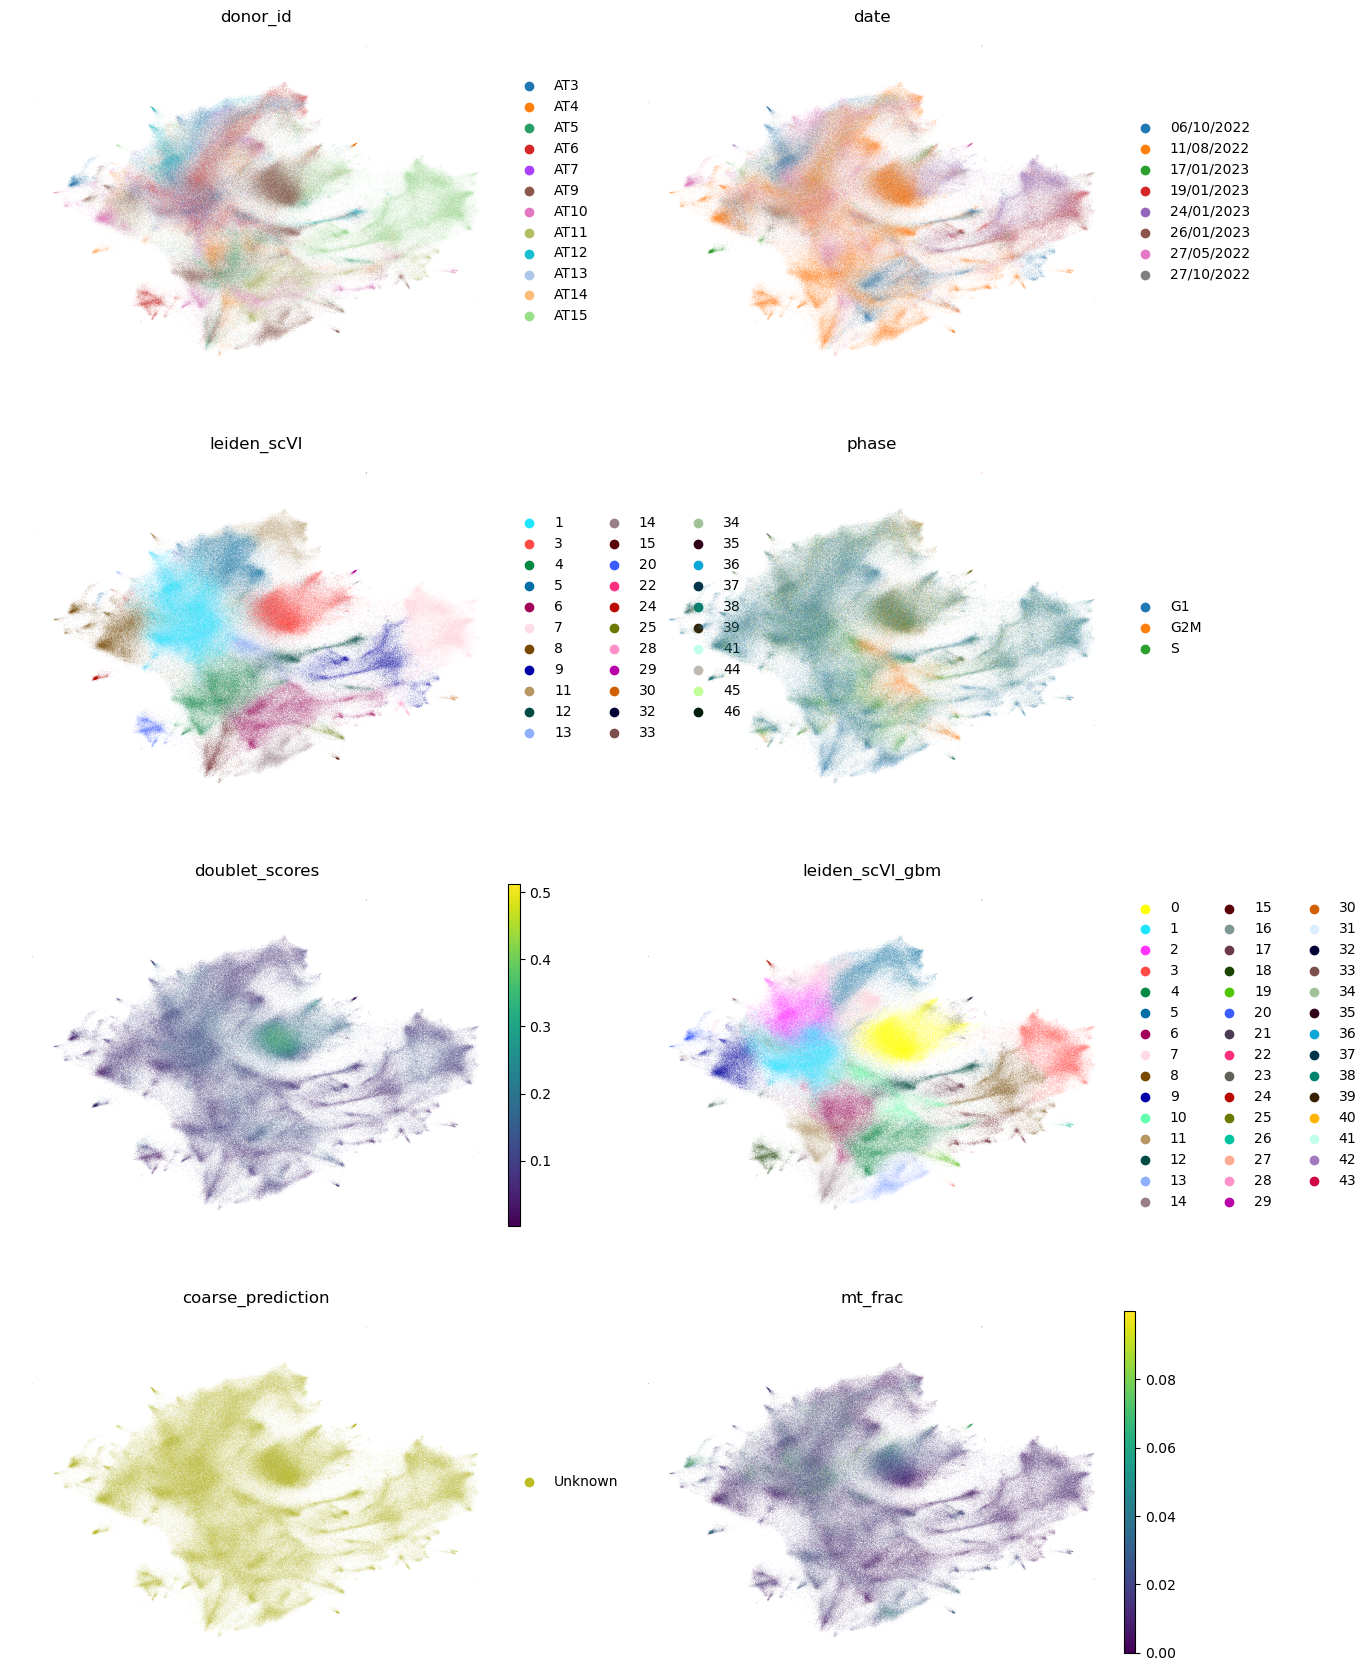

In [ ]:
# generate UMAP
sc.pl.umap(
    adata_gbm,
    color=["donor_id", "date", "leiden_scVI", "phase", "doublet_scores", 
           "leiden_scVI_gbm", "coarse_prediction", "mt_frac"],
    ncols=2,
    size=0.1,
    frameon=False)

In [ ]:
adata_gbm.raw.to_adata().write_h5ad('../data/adata/GBM_LEAP_GBM_only.h5ad')

# Rank CNA signal

## Filter spurious TME clusters

In [ ]:
cluster = 'leiden_scVI_gbm'

import seaborn as sns
import matplotlib.pyplot as plt

summary = adata_gbm.obs.groupby([cluster, 'malignant_signal'])[['cell_id']]\
    .count().reset_index()\
    .pivot(index=cluster, columns='malignant_signal', values='cell_id')
summary['perc_CNA'] = 100*(summary[1]/(summary[0]+summary[1]))
summary = summary.reset_index()

In [ ]:
non_malignant = summary[summary['perc_CNA']<5][cluster].tolist()

for i in non_malignant:
    adata_gbm.obs['check_{}'.format(i)] = np.where(adata_gbm.obs[cluster]==i, 'Check', '')

    # generate UMAP
    sc.pl.umap(
        adata_gbm,
        color=['check_{}'.format(i)],
        ncols=1,
        size=0.1,
        frameon=False)

In [ ]:
adata_gbm[adata_gbm.obs[cluster].isin(non_malignant)].obs.groupby([cluster, 'solo_prediction'])['cell_id'].count()

Series([], Name: cell_id, dtype: int64)

In [ ]:
# remove 
if len(adata_gbm[adata_gbm.obs[cluster].isin(non_malignant)])<500:
    adata_gbm[adata_gbm.obs[cluster].isin(non_malignant)].obs\
        .to_csv('/../data/QC/FILTERED_subclustering_additional.csv', 
                index=None)
    adata_gbm = adata_gbm[~adata_gbm.obs[cluster].isin(non_malignant)]

## Rank clusters

In [ ]:
cluster = 'leiden_scVI_gbm'

import seaborn as sns
import matplotlib.pyplot as plt

summary = adata_gbm.obs.groupby([cluster, 'malignant_signal'])[['cell_id']]\
    .count().reset_index()\
    .pivot(index=cluster, columns='malignant_signal', values='cell_id')
summary['perc_CNA'] = 100*(summary[1]/(summary[0]+summary[1]))
summary = summary.reset_index()

## Inspect clusters

In [ ]:
summary = adata_gbm.obs.groupby([cluster, 'malignant_signal'])[['cell_id']]\
    .count().reset_index()\
    .pivot(index=cluster, columns='malignant_signal', values='cell_id')
summary['perc_CNA'] = 100*(summary[1]/(summary[0]+summary[1]))
summary = summary.reset_index()


In [ ]:
cluster = 'leiden_scVI_gbm'

summary = adata_gbm.obs.groupby([cluster, 'malignant_signal'])[['cell_id']]\
    .count().reset_index()\
    .pivot(index=cluster, columns='malignant_signal', values='cell_id')
summary['perc_CNA'] = 100*(summary[1]/(summary[0]+summary[1]))
summary = summary.reset_index()

summary

malignant_signal,leiden_scVI_gbm,0,1,perc_CNA
0,0,52923,28471,34.979237
1,1,34596,33258,49.014060
2,2,20945,26209,55.581711
3,3,20148,23302,53.629459
4,4,17784,24726,58.165138
5,5,27791,14002,33.503218
6,6,24229,14654,37.687421
7,7,15326,22052,58.997271
8,8,12767,19953,60.981051
9,9,14597,13329,47.729714


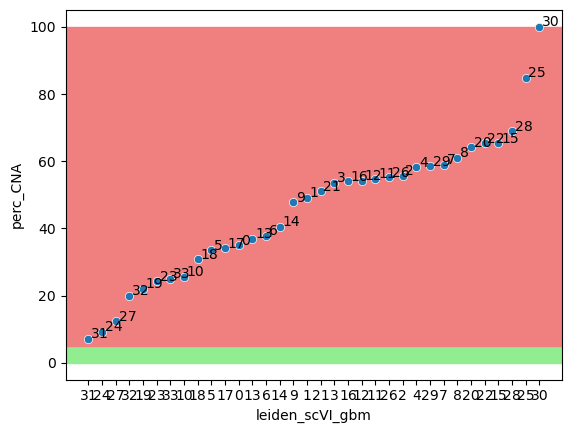

In [ ]:
plt.axhspan(0,5, color = 'lightgreen')
plt.axhspan(5,100, color = 'lightcoral')

summary = summary.sort_values('perc_CNA').reset_index(drop=True)
summary[cluster] = summary[cluster].astype(str)

sns.scatterplot(data=summary, x = cluster, y = 'perc_CNA')
for i, leiden in enumerate (summary[cluster]):
    plt.annotate(leiden, (float(i)+0.2, summary.loc[i]['perc_CNA']+0.2))

plt.show()

In [ ]:
adata_gbm.obs = adata_gbm.obs.reset_index().merge(
    summary[[cluster, 'perc_CNA']], on = cluster, how = 'left').set_index('index')

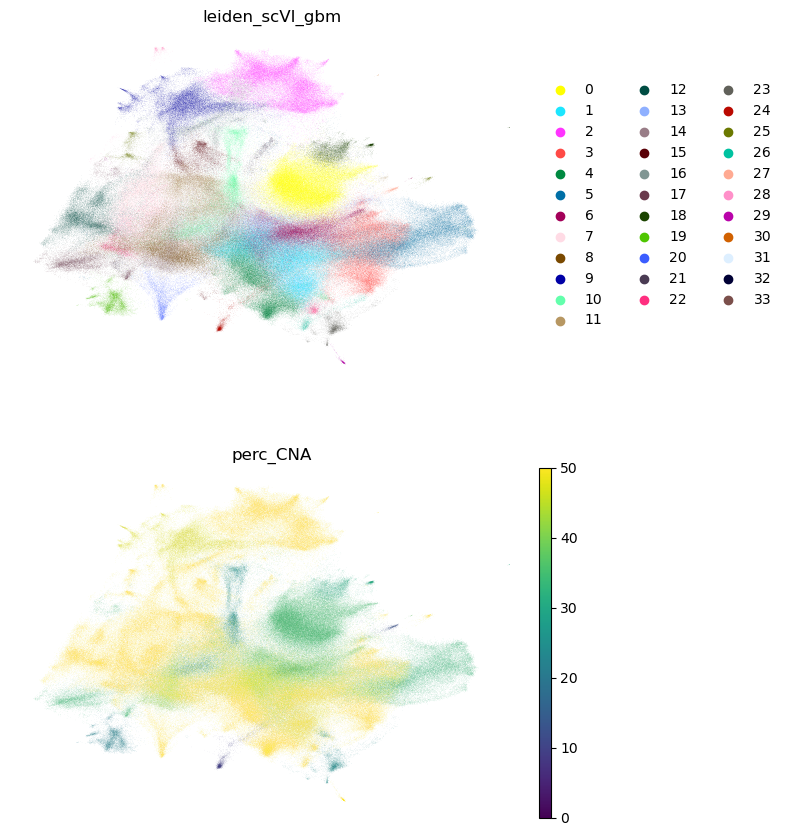

In [ ]:
# generate UMAP
sc.pl.umap(
        adata_gbm,
        color=[cluster, 'perc_CNA'],
        ncols=1,
        size=0.1, vmin=[0,0], vmax=[0,50],
        frameon=False)

# Aggregate spurious clusters

In [ ]:
# hierarchical clustering of leiden_scVI if <200 cells, merge with nearest neighbour
# rename leiden_scVI_gbm = leiden_scVI_gbm_unaggregated
# use name leiden_scVI_gbm
if 'leiden_scVI_gbm_unaggregated' not in adata_gbm.obs.columns:
    adata_gbm.obs['leiden_scVI_gbm_unaggregated'] = adata_gbm.obs['leiden_scVI_gbm'].copy()

In [ ]:
gbm_biomarkers_specific = {
    'AClike.3':['VEGFA'], # not exclusive, present in TME
    'AClike.4':['EEPD1'],
    'AClike.5':['DIAPH3', 'CENPK', 'C21orf58', 'SMC4'],
    'AClike.6':['PLXDC2'], # not exclusive, present in TME
    'AClike.7':['GALR1'], # not exclusive, present in TME
    'AClike_MESlike.1':['ABCC3'], # not exclusive, present in TME
    'AClike_MESlike.2':['CFAP54'], # not exclusive, present in TME # GFAP
    'AClike_NPClike.1':['CENPF', 'ARL6IP1'],
    'MESlike.1':['HILPDA', 'BNIP3L'],
    'MESlike.2':['AKAP12', 'NRP1'],
    'NPClike.1':['KCNH7', 'THSD7A', 'MYT1L'], # not exclusive, present in TME
    'OPClike.2':['KCND2', 'LHFPL3'],
    'OPClike.3':['MET'],
    'OPClike.4':['SCFD2', 'KIAA1211'],
    'OPClike.5':['HES6', 'DGKB', 'GRIA4'],
    'OPClike.6':['BCAS1', 'PKP4', 'TNS3'],
    'OPClike.8':['NTNG1']
 }

         Falling back to preprocessing with `sc.pp.pca` and default params.
categories: 0, 1, 2, etc.
var_group_labels: AClike.3, AClike.4, AClike.5, etc.


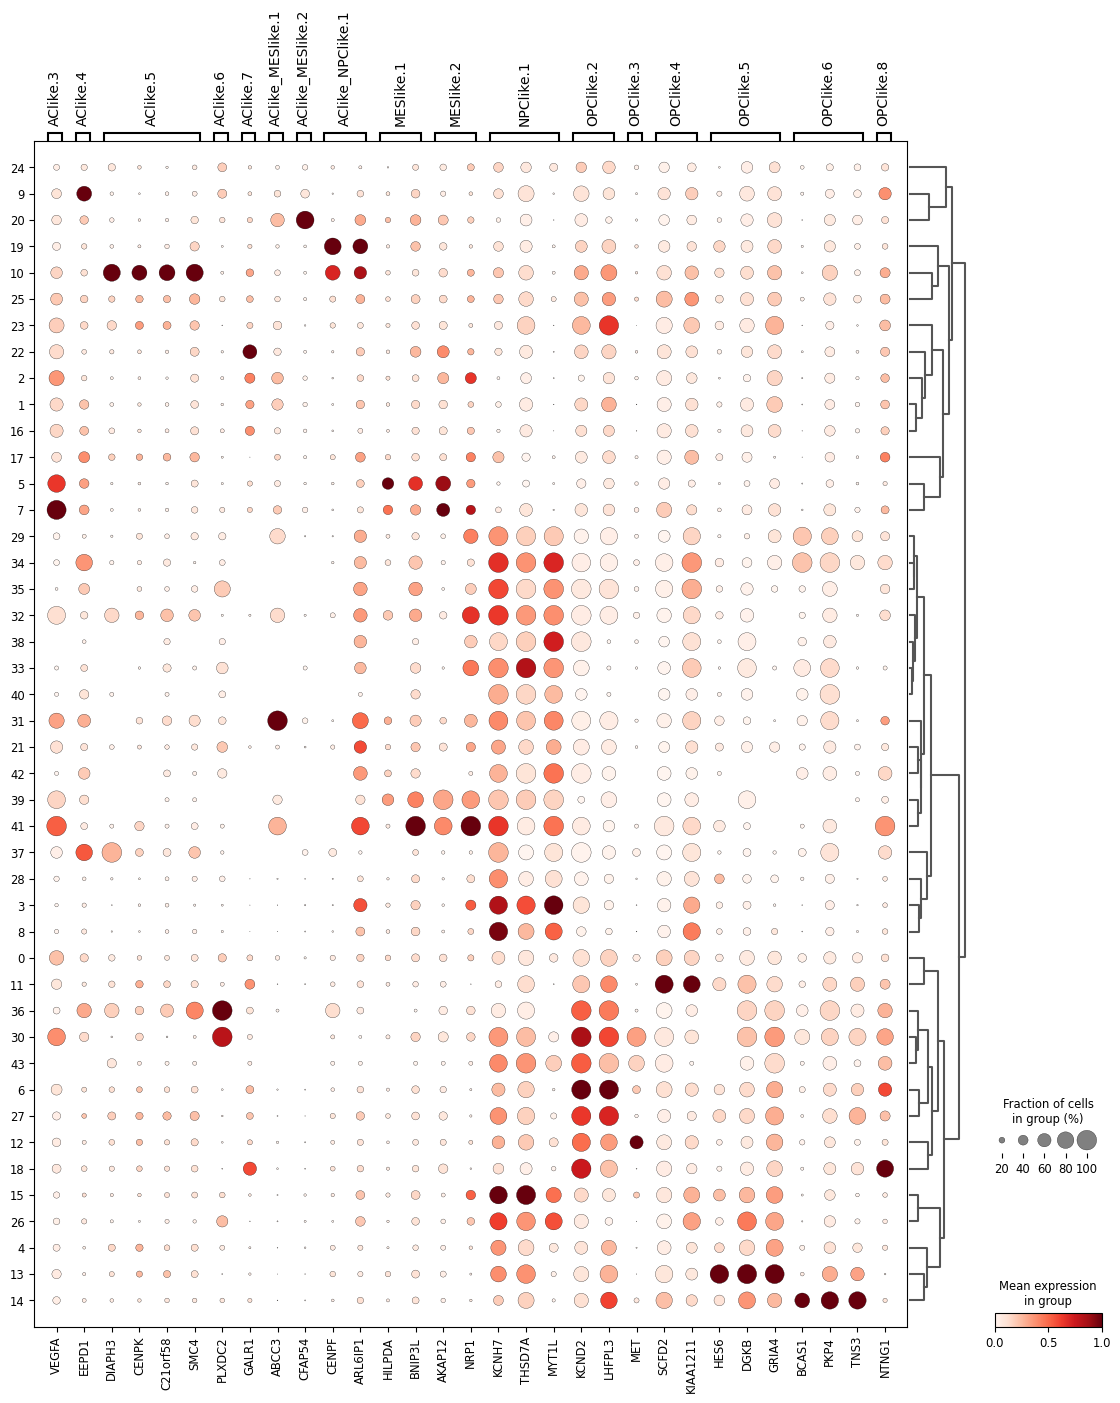

In [ ]:
sc.pl.dotplot(adata_gbm, 
              gbm_biomarkers_specific, 
              groupby='leiden_scVI_gbm', 
              dendrogram=True, gene_symbols="SYMBOL", standard_scale='var')

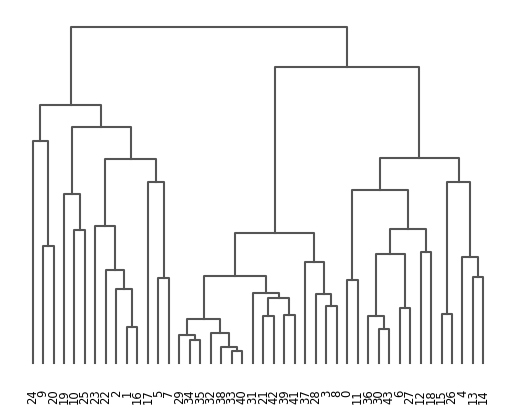

<AxesSubplot:>

In [ ]:
sc.pl.dendrogram(adata_gbm, 'leiden_scVI_gbm')

## Get highest cluster correlates

In [ ]:
# use scanpy method
from scanpy import plotting
from scanpy import tools
import scipy.cluster.hierarchy as sch
from scipy.spatial import distance

In [ ]:
adata_gbm.obs['leiden_scVI_gbm'] = adata_gbm.obs['leiden_scVI_gbm_1.2'].copy()

cluster_dist = adata_gbm.obs.groupby(['donor_id', 'leiden_scVI_gbm'])['cell_id'].count().reset_index()
cluster_dist = cluster_dist.pivot(index=['leiden_scVI_gbm'], columns = 'donor_id',values = 'cell_id')
cluster_dist

donor_id,AT3,AT4,AT5,AT6,AT7,AT9,AT10,AT11,AT12,AT13,AT14,AT15
leiden_scVI_gbm,,,,,,,,,,,,
0,15865,4324,490,31302,7495,882,338,133,732,11789,4908,1679
1,4240,2659,4291,3496,446,40460,862,1201,809,828,3312,15096
2,13091,1811,224,7714,1490,500,186,98,21795,1786,2183,743
3,83,141,195,18,2,282,116,132,28,1,41,47055
4,98,2406,1572,280,1118,1989,11798,25654,14,44,90,2726
5,8638,2399,854,18628,1188,2246,804,611,3906,1061,2903,4074
6,431,3253,1050,602,628,6019,11676,3908,22,1116,85,2752
7,114,13487,10990,426,318,3028,1259,792,57,8,22,336
8,5,22,30,55,0,121,358,67,8,0,660,25090


In [ ]:
groupby = 'leiden_scVI_gbm'

# Format adata PCAs for clustering; use dendrogram defaults
groupby = [groupby]
rep_df = pd.DataFrame(
            tools._utils._choose_representation(adata_gbm, use_rep='X_pca', n_pcs=50)
        )

# In case more categories used; probably only one though
if len(groupby) > 1:
    for group in groupby[1:]:
        # create new category by merging the given groupby categories
        categorical = (
            categorical.astype(str) + "_" + adata.obs[group].astype(str)
            ).astype('category')
categorical = adata_gbm.obs[groupby[0]]
categorical.name = "_".join(groupby)
rep_df.set_index(categorical, inplace=True)
categories = rep_df.index.categories

# Get category (cluster) means
mean_df = rep_df.groupby(level=0).mean()

# get corr matrix distances
corr_matrix = mean_df.T.corr(method='pearson')
np.fill_diagonal(corr_matrix.values, -2.)

In [ ]:
# get list of under-populated clusters
low_population_clusters = cluster_dist.sum(axis=1).reset_index()
low_population_clusters = low_population_clusters[low_population_clusters[0]<1000]['leiden_scVI_gbm'].tolist()

In [ ]:
# filter corr matrix to only include high-pop clusters and take the highest correlated high-pop cluster
columns = corr_matrix.columns[~corr_matrix.columns.isin(low_population_clusters)]
corr_matrix = corr_matrix[columns]
correlates = pd.DataFrame(corr_matrix.idxmax(axis=1)).reset_index()
correlates = correlates[correlates['leiden_scVI_gbm'].isin(low_population_clusters)]

In [ ]:
correlates

,leiden_scVI_gbm,0
29,29,25
30,30,18
31,31,7
32,32,15
33,33,19
34,34,19
35,35,19
36,36,8
37,37,19
38,38,15


In [ ]:
if 'cluster_colrrelate' not in adata_gbm.obs.columns:
    adata_gbm.obs = adata_gbm.obs.reset_index().merge(correlates.rename(columns={0:'cluster_colrrelate'}), 
                                      on = 'leiden_scVI_gbm', how = 'left').set_index('index')
else:
    del(adata_gbm.obs['cluster_colrrelate'])
    adata_gbm.obs = adata_gbm.obs.reset_index().merge(correlates.rename(columns={0:'cluster_colrrelate'}), 
                                      on = 'leiden_scVI_gbm', how = 'left').set_index('index')

In [ ]:
adata_gbm.obs['leiden_scVI_gbm'] = np.where(adata_gbm.obs['cluster_colrrelate'].isnull(),
                                           adata_gbm.obs['leiden_scVI_gbm'], adata_gbm.obs['cluster_colrrelate'])

In [ ]:
cluster_dist = adata_gbm.obs.groupby(['donor_id', 'leiden_scVI_gbm'])['cell_id'].count().reset_index()
cluster_dist = cluster_dist.pivot(index=['leiden_scVI_gbm'], columns = 'donor_id',values = 'cell_id')
cluster_dist

donor_id,AT3,AT4,AT5,AT6,AT7,AT9,AT10,AT11,AT12,AT13,AT14,AT15
leiden_scVI_gbm,,,,,,,,,,,,
0,15865,4324,490,31302,7495,882,338,133,732,11789,4908,1679
1,4240,2659,4291,3496,446,40460,862,1201,809,828,3312,15096
10,410,5591,564,359,1357,6088,5125,311,29,685,127,675
11,73,190,364,54,56,14176,4337,276,2,6,6,108
12,9820,1049,443,790,1809,725,1468,132,219,99,303,1486
13,32,207,1146,190,13,8281,954,107,5093,0,15,950
14,4,140,138,11,11,14327,204,101,0,0,3,47
15,167,605,10056,164,10,2706,88,40,19,0,14,35
16,8,17,9,172,17,24,52,7,2,6,336,12618


## Flag tumour-specific clusters

In [ ]:
# calculate CV for clusters
high_var_clusters = cluster_dist.std(axis=1).divide(cluster_dist.mean(axis=1)).reset_index().rename(columns={0:'CV'})
high_var_clusters.sort_values('CV')

,leiden_scVI_gbm,CV
16,23,0.591455
28,9,0.690925
19,26,0.997754
25,6,1.289517
24,5,1.303314
2,10,1.316684
10,18,1.334449
9,17,1.356493
0,0,1.388799
12,2,1.564434


In [ ]:
if 'CV' not in adata_gbm.obs.columns:
    adata_gbm.obs = adata_gbm.obs.reset_index().merge(high_var_clusters, 
                                      on = 'leiden_scVI_gbm', how = 'left').set_index('index')
else:
    del(adata_gbm.obs['CV'])
    adata_gbm.obs = adata_gbm.obs.reset_index().merge(high_var_clusters, 
                                      on = 'leiden_scVI_gbm', how = 'left').set_index('index')

# Neftel module scores

## Generate score and annotate

In [ ]:
modules = pd.read_csv('../data/metadata/neftel_module_scores.csv')

In [ ]:
adata_gbm.X = adata_gbm.layers['counts'].copy()

# i.e. scanpy/seurat methods
sc.pp.normalize_total(adata_gbm, target_sum=1e4)
sc.pp.log1p(adata_gbm)
sc.pp.scale(adata_gbm)

In [ ]:
score_list = []
for i in modules.columns:
    gene_list = modules[i].dropna().tolist()
    sc.tl.score_genes(adata_gbm, gene_list, score_name=i+'_score', use_raw=False)
    score_list.append(i+'_score')

In [ ]:
module_vmax=[]
for i in score_list:
    module_vmax.append(adata_gbm.obs[i].quantile(0.98))

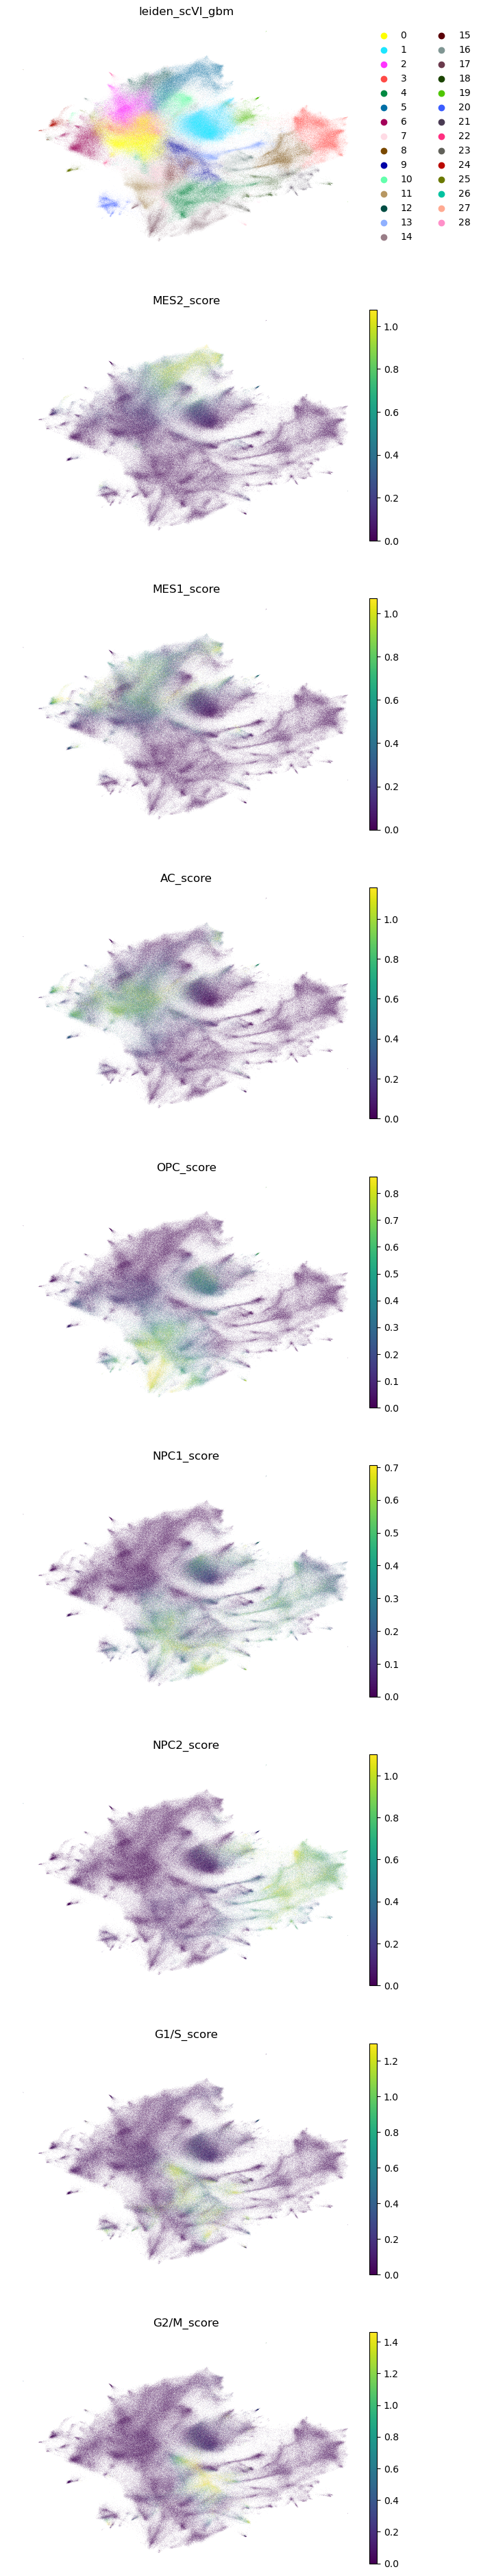

In [ ]:
sc.pl.umap(
        adata_gbm,
        color=['leiden_scVI_gbm']+score_list,
        ncols=1,
        vmax=[0]+module_vmax,
        vmin=0,
        size=0.1,
        frameon=False)

In [ ]:
score_list = ['MES2_score',
 'MES1_score',
 'AC_score',
 'OPC_score',
 'NPC1_score',
 'NPC2_score']

adata_gbm.obs['GBS_high_score'] = adata_gbm.obs[score_list].idxmax(axis=1)
adata_gbm.obs['GBS_top_value'] = adata_gbm.obs[score_list].max(axis=1)
adata_gbm.obs['GBS_annotation'] = np.where(adata_gbm.obs['GBS_top_value']<0, 
                                           'Undefined', adata_gbm.obs['GBS_high_score'])

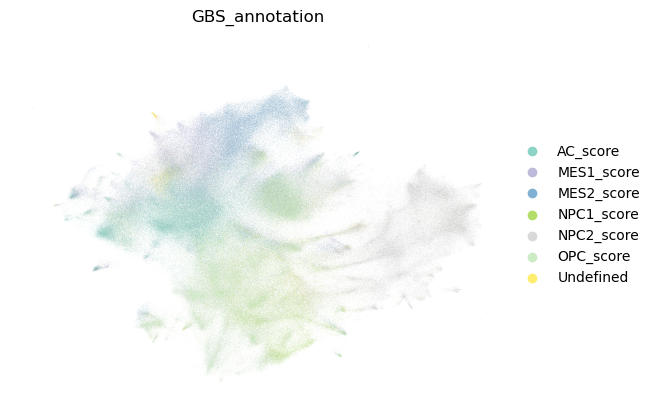

In [ ]:
sc.pl.umap(
        adata_gbm,
        color=['GBS_annotation'],
        ncols=1,
        vmax=[0]+module_vmax,
        size=0.1,
        palette="Set3",
        frameon=False)

## Plot scores

In [ ]:
GS_for_plot = adata_gbm.obs[['GBS_high_score']+score_list].reset_index()

In [ ]:
GS_out = []
for i in set(GS_for_plot['GBS_high_score']):
    GS = GS_for_plot[GS_for_plot['GBS_high_score']==i]
    GS = GS.sort_values(i, ascending=False)
    GS_out.append(GS)
GS_out = pd.concat(GS_out, ignore_index=False)
GS_out.index = range(len(GS_out))

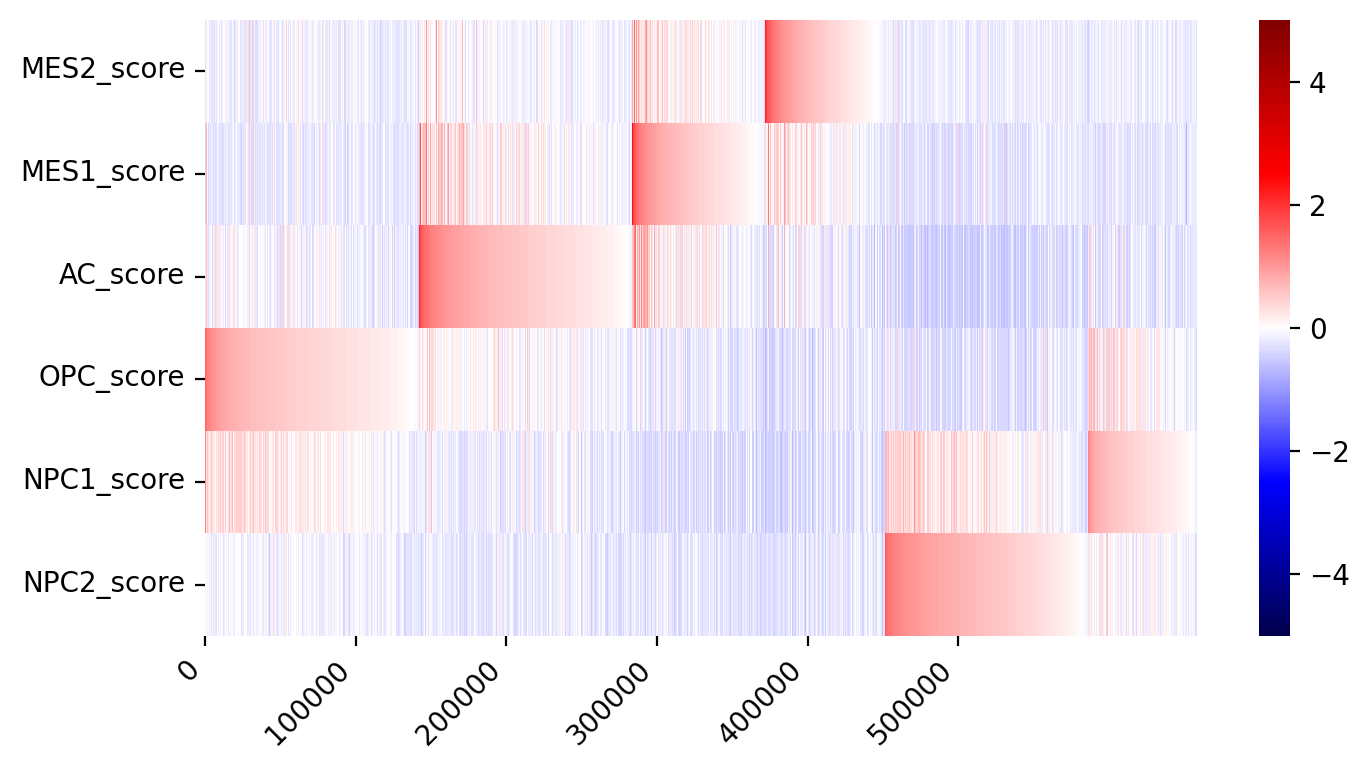

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 4), dpi=200)

sns.heatmap(GS_out[score_list].transpose(), 
            annot=False, cmap="seismic", center=0, vmax=5, vmin=-5)
plt.yticks(rotation=0)
plt.xticks(ticks=np.arange(0, 600000, 100000), 
           labels = np.arange(0, 600000, 100000),
          rotation=45, ha='right')
plt.show()
plt.savefig('GS_heatmap_score.png')

# Assign scores labels

## Create label

In [ ]:
# create label
totals = adata_gbm.obs.groupby(['leiden_scVI_gbm'], as_index=False)['cell_id'].count()\
    .rename(columns={'cell_id':'totals'})
leiden_props = adata_gbm.obs.groupby(['leiden_scVI_gbm', 'GBS_high_score'], as_index=False)['cell_id']\
    .count()\
    .merge(totals, on = 'leiden_scVI_gbm')
leiden_props['proportion'] = leiden_props['cell_id']/leiden_props['totals']

leiden_names = leiden_props[leiden_props['proportion']>0.25]\
    .groupby('leiden_scVI_gbm', as_index=False).agg({'GBS_high_score':lambda x: '_'.join(sorted(x))})

In [ ]:
# get per-module distribution info
module_min=[]
for i in score_list:
    module_min.append(
        pd.DataFrame({'GBS_high_score':i, 'median':adata_gbm.obs[i].quantile(0.5)}, index=[0]))
module_min = pd.concat(module_min, ignore_index=True)

if 'median' not in adata_gbm.obs.columns:
    adata_gbm.obs = adata_gbm.obs.reset_index()\
        .merge(module_min, on = 'GBS_high_score', how='left')\
        .set_index('index')
else:
    del(adata_gbm.obs['median'])
    adata_gbm.obs = adata_gbm.obs.reset_index()\
        .merge(module_min, on = 'GBS_high_score', how='left')\
        .set_index('index')

In [ ]:
# add low score information
adata_gbm.obs['GBS_low'] = np.where(adata_gbm.obs['GBS_top_value']<adata_gbm.obs['median'], 1, 0)

low_score_leiden = adata_gbm.obs.groupby('leiden_scVI_gbm', as_index=False)['GBS_low'].sum()\
    .merge(totals, on = 'leiden_scVI_gbm')
low_score_leiden['low_score_proportion'] = low_score_leiden['GBS_low'].divide(low_score_leiden['totals'])
leiden_names = leiden_names.merge(low_score_leiden[['leiden_scVI_gbm', 
                                                    'low_score_proportion']], on = 'leiden_scVI_gbm')

In [ ]:
# mark low-scoring clusters
leiden_names['GBS_high_score'] = np.where(leiden_names['low_score_proportion']>0.2, 'Undefined',
                                         leiden_names['GBS_high_score'])

In [ ]:
# clean labels
leiden_names['N'] = leiden_names.groupby('GBS_high_score', as_index=False).cumcount()+1
leiden_names['GBM_granular'] = leiden_names['GBS_high_score']+"."+leiden_names['N'].astype(str)
leiden_names = leiden_names.drop(['GBS_high_score', 'N'], axis=1)
leiden_names['GBM_granular'] = [re.sub('_score', 'like', i) for i in leiden_names['GBM_granular']]

<Figure size 640x480 with 0 Axes>

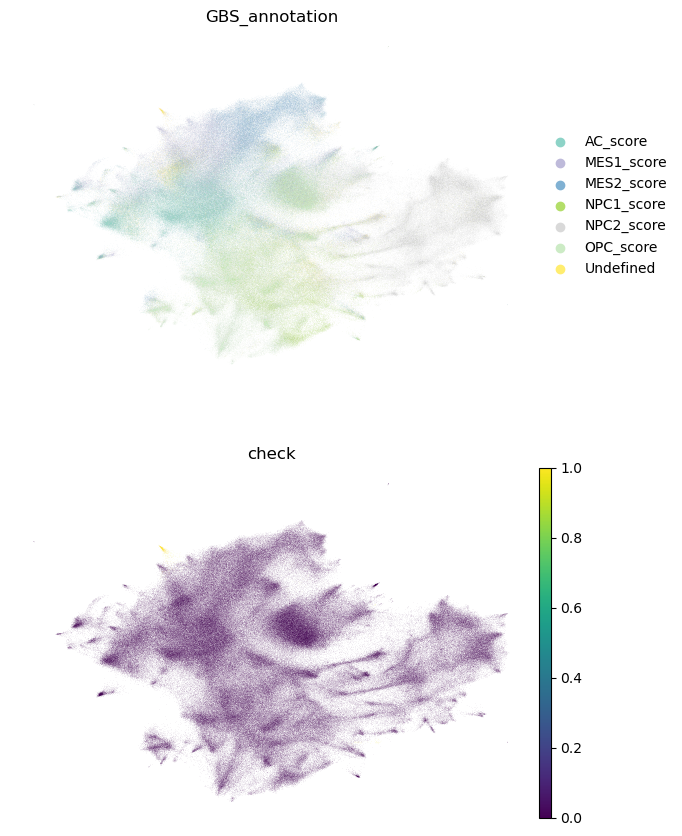

In [ ]:
low_scoring_clusters = leiden_names[leiden_names['low_score_proportion']>0.2]['leiden_scVI_gbm'].tolist()
adata_gbm.obs['check'] = np.where(
    adata_gbm.obs['leiden_scVI_gbm'].isin(low_scoring_clusters), 1, 0)
sc.pl.umap(
        adata_gbm,
        color=['GBS_annotation', 'check'],
        ncols=1,
        size=0.1,
        palette="Set3",
        frameon=False)

In [ ]:
if 'GBM_granular' not in adata_gbm.obs.columns:
    adata_gbm.obs = adata_gbm.obs.reset_index()\
        .merge(leiden_names[['leiden_scVI_gbm', 'GBM_granular']], on = 'leiden_scVI_gbm', how='left')\
        .set_index('index')
else:
    del(adata_gbm.obs['GBM_granular'])
    adata_gbm.obs = adata_gbm.obs.reset_index()\
        .merge(leiden_names[['leiden_scVI_gbm', 'GBM_granular']], on = 'leiden_scVI_gbm', how='left')\
        .set_index('index')

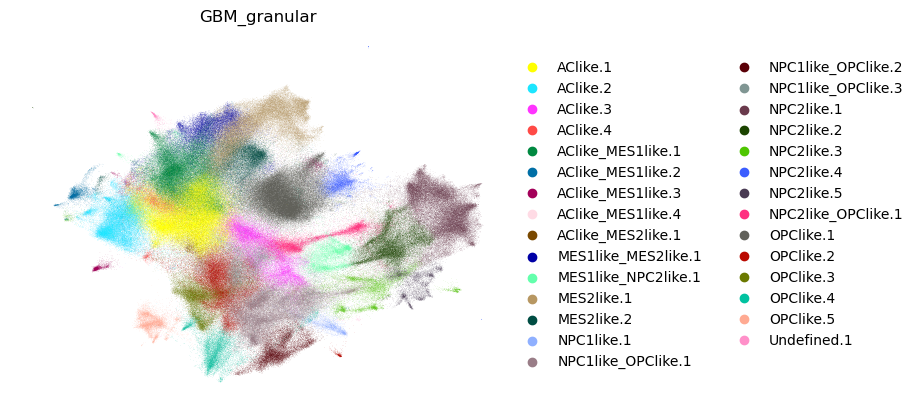

In [ ]:
sc.pl.umap(
    adata_gbm,
    color=["GBM_granular"],
    frameon=False)

# DGE analysis

In [ ]:
sc.tl.rank_genes_groups(adata_gbm, 'leiden_scVI_gbm', method='wilcoxon', key_added = "wilcoxon", use_raw=False)

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scanpy/tools/_rank_genes_groups.py:421: RuntimeWarning: invalid value encountered in log2
  foldchanges[global_indices]
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axi

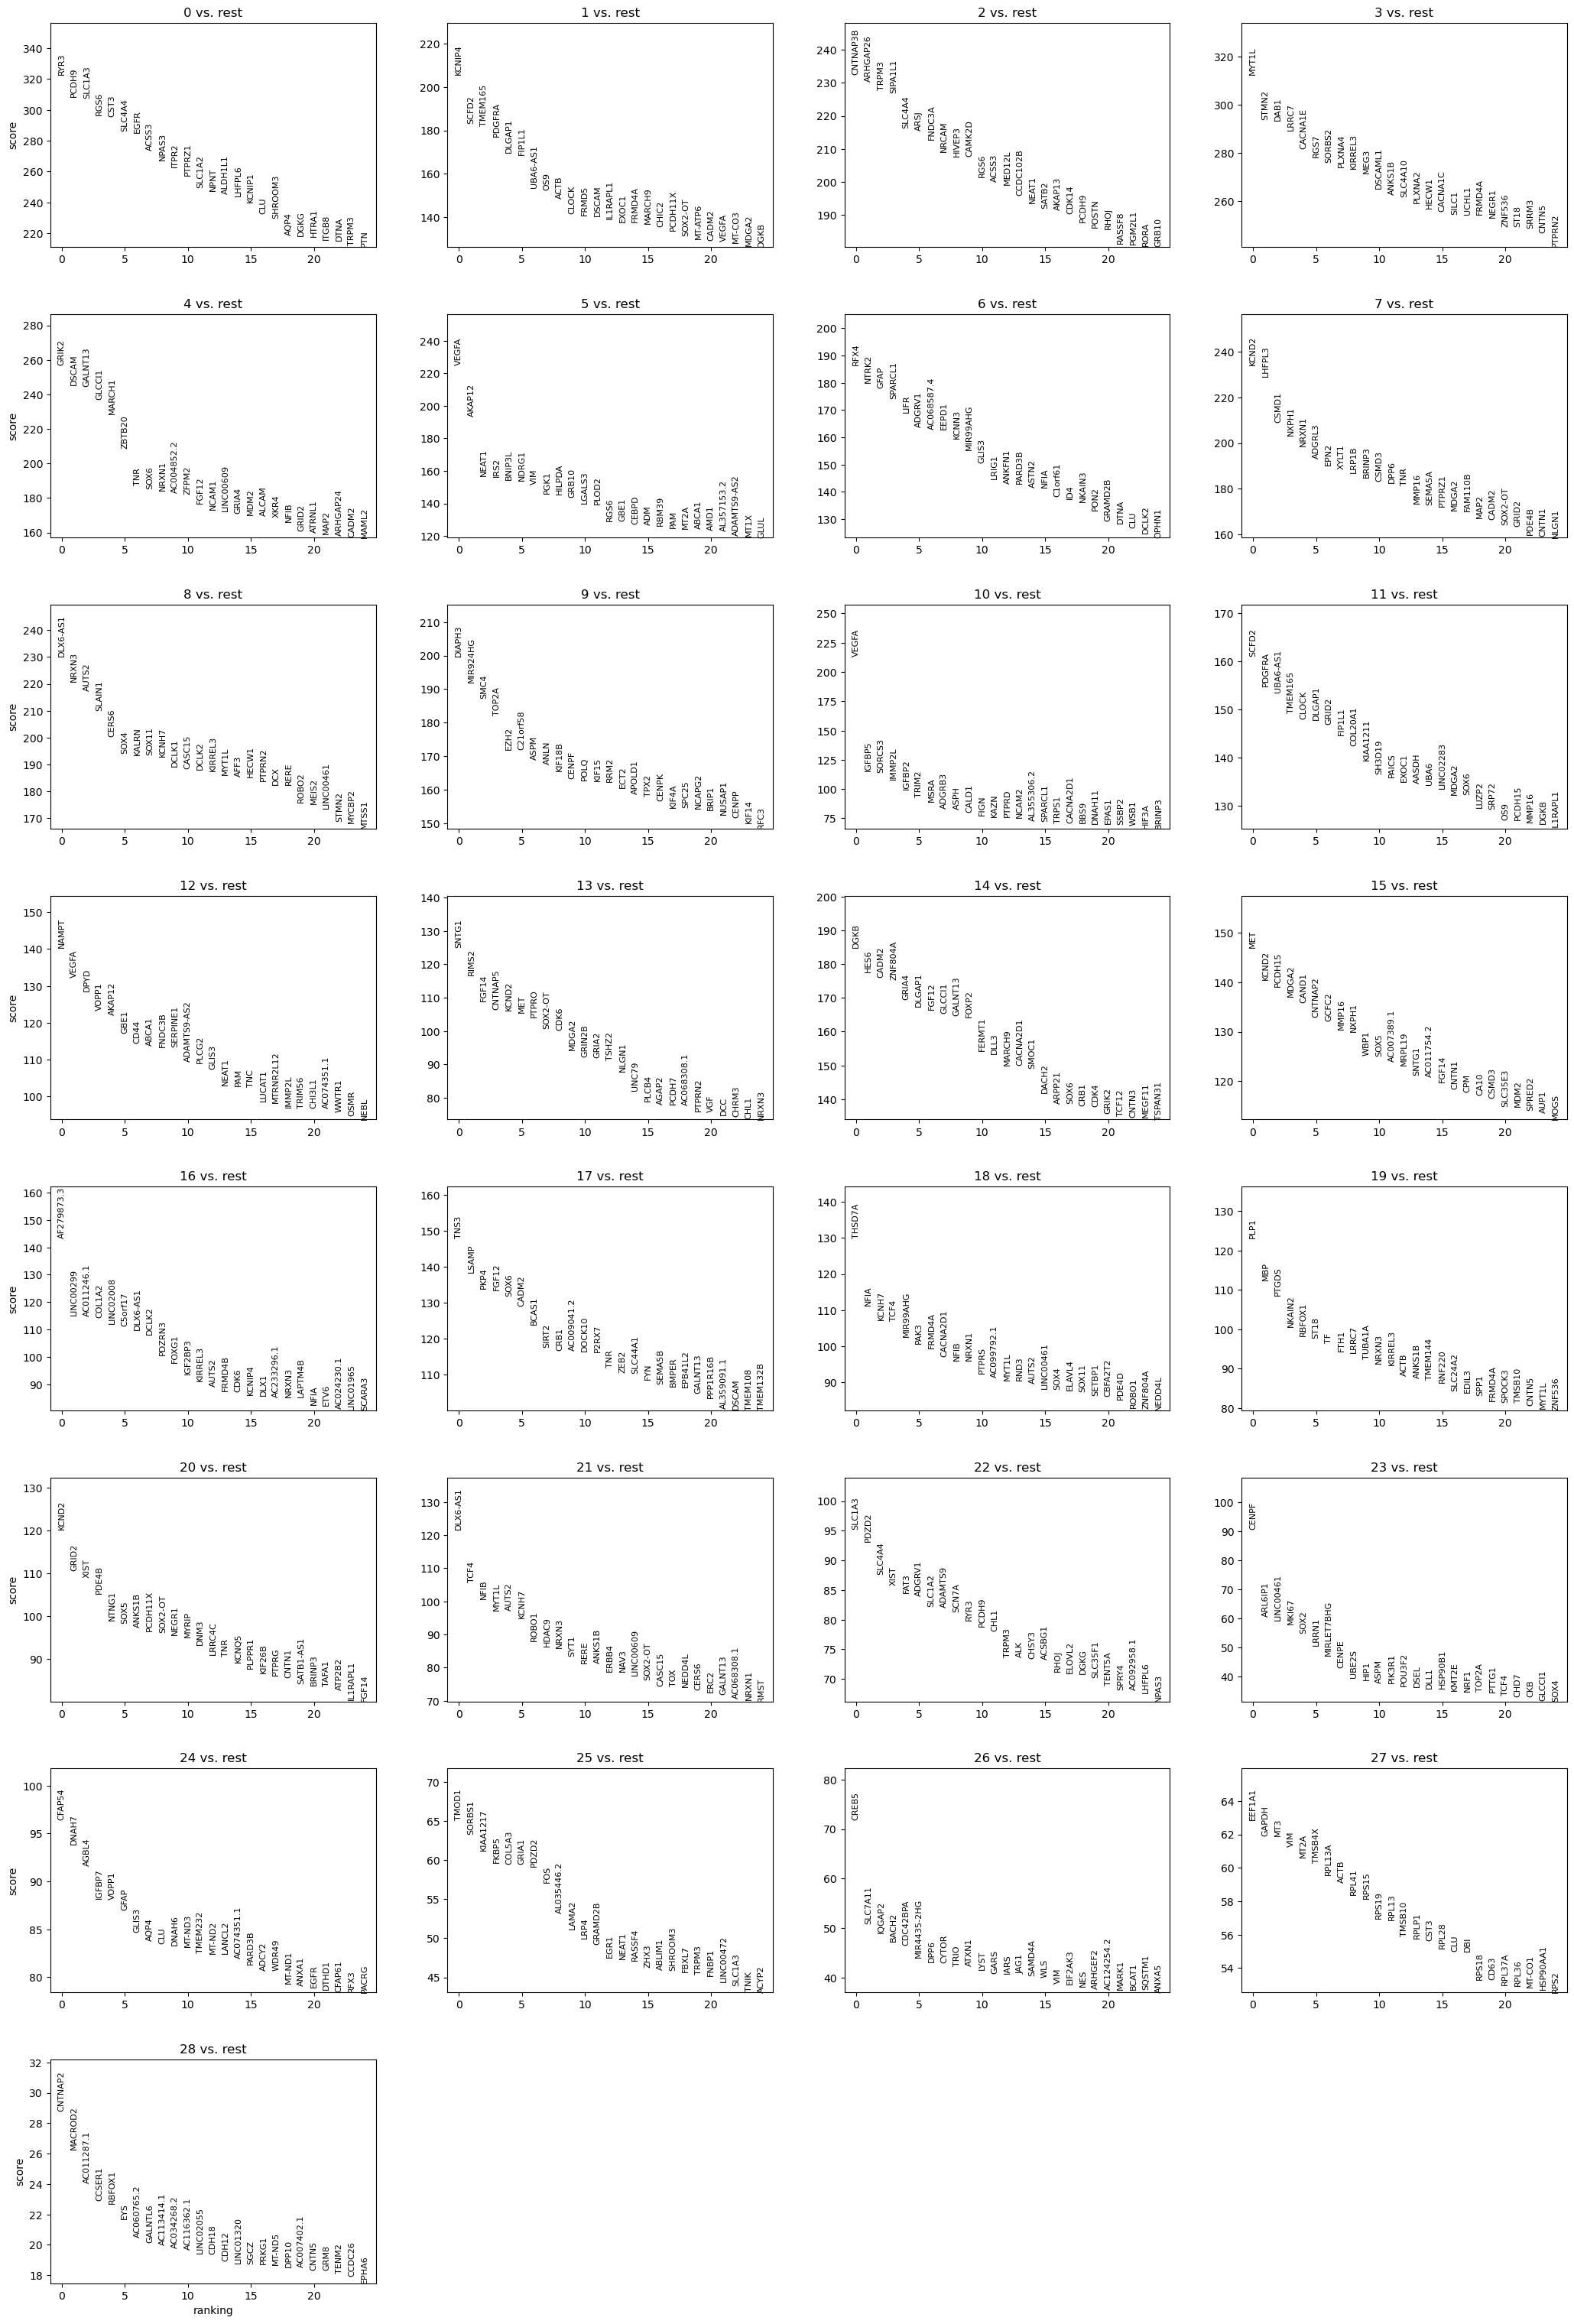

In [ ]:
sc.pl.rank_genes_groups(adata_gbm, n_genes=25, sharey=False, key="wilcoxon")

In [ ]:
DNA_damage_repair = ["ATM", "ATR", "PRKDC", "CHEK2", "CHEK1", "WEE1", "PARP1"]

In [ ]:
sc.tl.score_genes(adata_gbm, DNA_damage_repair, 
                  score_name='DNA_repair_score')

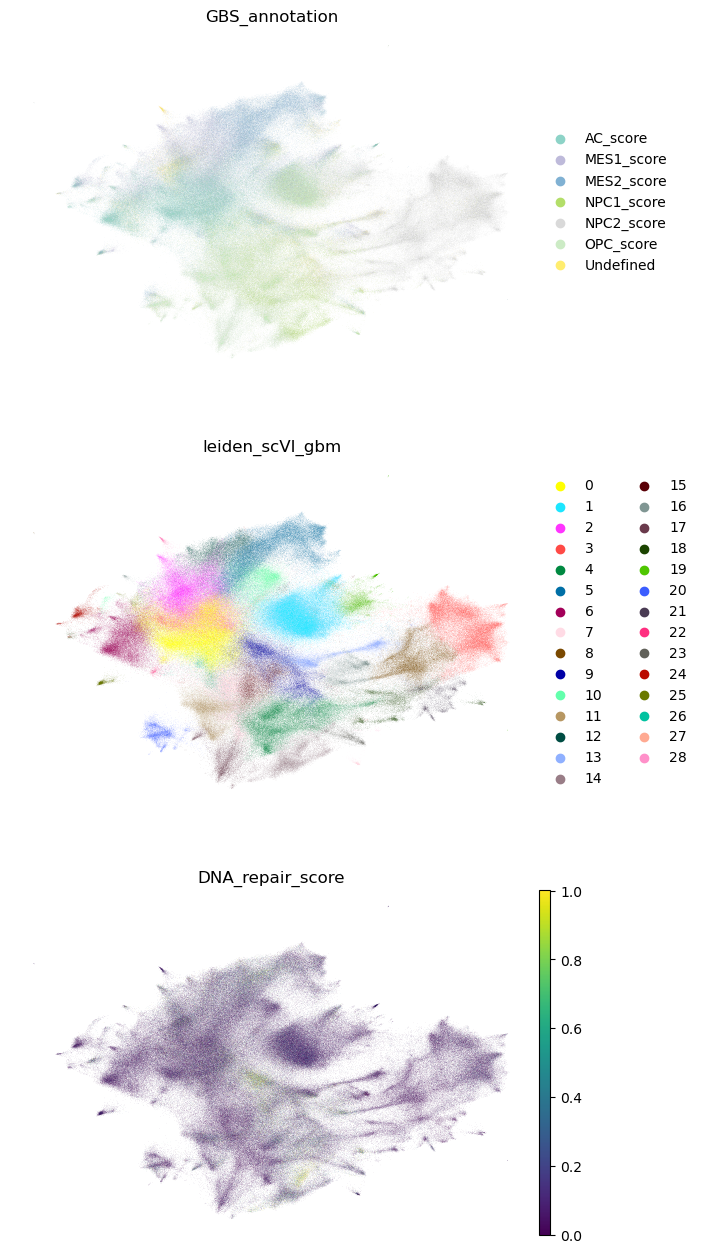

In [ ]:
sc.pl.umap(
        adata_gbm,
        color=['GBS_annotation', 'leiden_scVI_gbm', 'DNA_repair_score'],
        ncols=1,
        size=0.1,
        vmax = [0, 0, adata_gbm.obs['DNA_repair_score'].quantile(0.98)],
        vmin = 0,
        palette = None,
        frameon=False)

In [ ]:
adata_gbm.write_h5ad('../data/adata/GBM_LEAP_GBM.h5ad')

# Functional annotation

## MSigDB

In [ ]:
from pandas import read_table
import pandas as pd
import matplotlib.pyplot as plt
import decoupler
import seaborn
import seaborn.objects as so
from pathlib import Path

def gmt_to_decoupler(pth: Path) -> pd.DataFrame:
    """
    Parse a gmt file to a decoupler pathway dataframe.
    """
    from itertools import chain, repeat

    pathways = {}

    with Path(pth).open("r") as f:
        for line in f:
            name, _, *genes = line.strip().split("\t")
            pathways[name] = genes

    return pd.DataFrame.from_records(
        chain.from_iterable(zip(repeat(k), v) for k, v in pathways.items()),
        columns=["geneset", "genesymbol"],
    )

In [ ]:
sc.pp.highly_variable_genes(
    adata_gbm, n_top_genes=4000, flavor="seurat_v3", subset=False, layer="counts"
)

In [ ]:
all_t_stats = {}
for i in adata_gbm.obs['leiden_scVI_gbm'].cat.categories:
    t_stats = (
        # Get dataframe of DE results for condition vs. rest
        sc.get.rank_genes_groups_df(adata_gbm, group = i, key = 'wilcoxon')    
        # Subset to highly variable genes
        .set_index("names")
        .loc[adata_gbm.var["highly_variable"]]
        # Sort by absolute score
        .sort_values("scores", key=np.abs, ascending=False)
        # Format for decoupler
        [["scores"]]
        .rename_axis([i], axis=1)
    )
    all_t_stats[i] = t_stats

In [ ]:
msigdb_path = '../data/metadata/functional_annotation/msigdb/msigdb_v2023.1.Hs_GMTs/'

# C5 - GO
# H - Hallmarks
# C8 - cell types 

set_ids = ['c5.go.bp.v2023.1.Hs.symbols.gmt', 'c5.go.cc.v2023.1.Hs.symbols.gmt', 'c5.go.mf.v2023.1.Hs.symbols.gmt',
           'h.all.v2023.1.Hs.symbols.gmt', 'c8.all.v2023.1.Hs.symbols.gmt', 'c2.all.v2023.1.Hs.symbols.gmt']


In [ ]:
signatures = []
for i in range(len(set_ids)):
     signatures.append(gmt_to_decoupler(msigdb_path+set_ids[i]))
signatures = pd.concat(signatures, ignore_index = True)

geneset_size = signatures.groupby("geneset").size()
gsea_genesets = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)]

In [ ]:
gsea_results_all = {}
for i in all_t_stats.keys():
    print(i)
    scores, norm, pvals = decoupler.run_gsea(
        all_t_stats[i].T,
        signatures[signatures["geneset"].isin(gsea_genesets)],
        source="geneset",
        target="genesymbol",
    )

    gsea_results = (
        pd.concat({"score": scores.T, "norm": norm.T, "pval": pvals.T}, axis=1)
        .droplevel(level=1, axis=1)
        .sort_values("pval")
    )
    gsea_results_all[i] = gsea_results

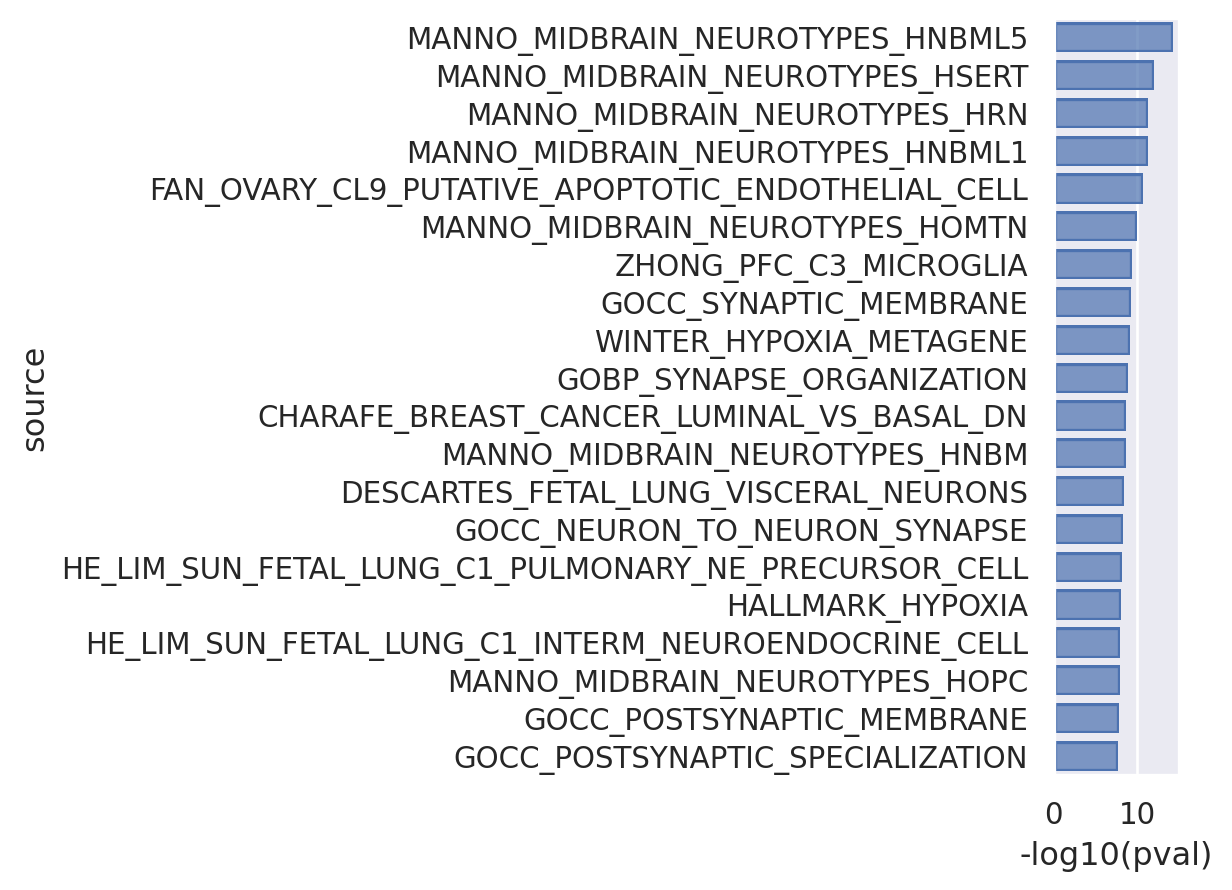

In [ ]:
(
    so.Plot(
        data=(
            gsea_results_all['5'].head(20).assign(
                **{"-log10(pval)": lambda x: -np.log10(x["pval"])}
            )
        ),
        x="-log10(pval)",
        y="source",
    ).add(so.Bar())
)

In [ ]:
for i in gsea_results_all.keys():
    gsea_results_all[i].to_csv(
        '../data/annotations/malignant/ORA_results_{}.txt'.format(i))
 

In [ ]:
functional_annotations = []
for i in set(adata_gbm.obs['leiden_scVI_gbm']):
    annos = pd.read_csv('../data/annotations/malignant/ORA_results_{}.txt'.format(i))
    annos['leiden_scVI_gbm'] = i
    functional_annotations.append(annos)
functional_annotations = pd.concat(functional_annotations, ignore_index=True)\
.merge(adata_gbm.obs[['leiden_scVI_gbm', 'GBM_granular']].drop_duplicates(),
                                         on = 'leiden_scVI_gbm')

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/seaborn/_core/plot.py:941: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.savefig(buffer, dpi=dpi * 2, format="png", bbox_inches="tight")


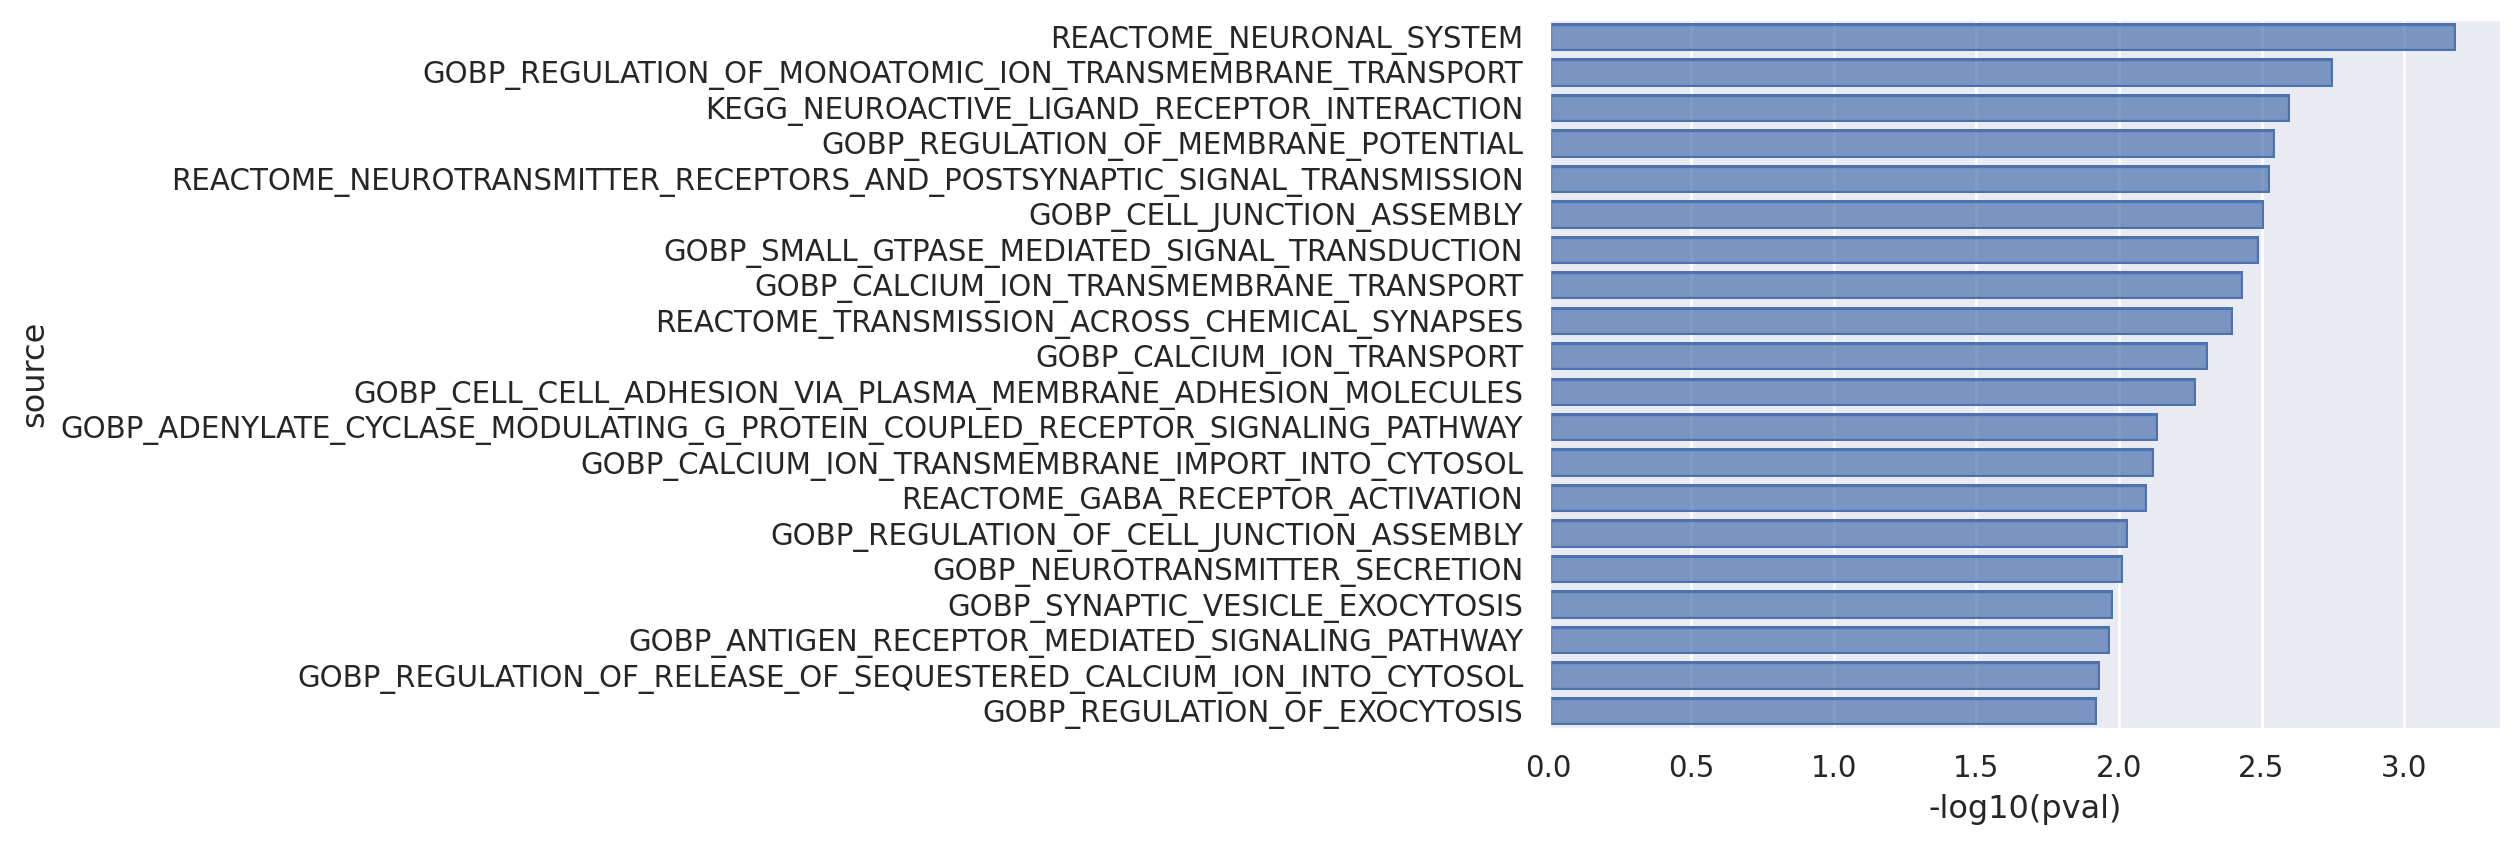

In [ ]:
test = functional_annotations[(functional_annotations['GBM_granular']=='Undefined.1') &
                                   (functional_annotations['norm']>0)]

(
    so.Plot(
        data=(
            test[(test['source'].str.contains('GOBP')) | 
     (test['source'].str.contains('KEGG')) |
     (test['source'].str.contains('REACTOME'))].head(20).assign(
                **{"-log10(pval)": lambda x: -np.log10(x["pval"])}
            )
        ),
        x="-log10(pval)",
        y="source",
    ).add(so.Bar())
)